# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 2. Data Loading and Initial Exploration
### Load the dataset and display first 10 rows

In [2]:
df = pd.read_csv('train.csv')
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


### Summary of the dataset

In [3]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data types of each column:")
df.dtypes

Dataset shape: 1460 rows, 81 columns

Data types of each column:


Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

### Identify columns with missing values and their percenteges

In [4]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count':missing, 'Percentage':missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print("Columns with missing values:")
missing_df

Columns with missing values:


,Missing Count,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


# 3.Data Cleaning and Preprocessing
### Handle missing values
First, separate numerical and categorical columns.

In [5]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

### Numerical columns: Impute missing values with the median of the column

In [6]:
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df.fillna({col: median_val}, inplace=True)
        print(f"Imputed '{col}' with median: {median_val}")

Imputed 'LotFrontage' with median: 69.0
Imputed 'MasVnrArea' with median: 0.0
Imputed 'GarageYrBlt' with median: 1980.0


### Categorical columns:
* Drop columns where missing values exceed 50%
* For the remaining, impute with mode (most frequent value).

In [7]:
# Drop categorical columns with >50% missing
threshold = 50
cols_to_drop = []
for col in categorical_cols:
    missing_pct = df[col].isnull().mean() * 100
    if missing_pct > threshold:
        cols_to_drop.append(col)
        print(f"Dropping '{col}' because {missing_pct:.2f}% missing (>50%)")
df.drop(columns=cols_to_drop, inplace=True)

# Update categorical columns list after dropping
categorical_cols = [col for col in categorical_cols if col not in cols_to_drop]

# Impute remaining categorical columns with mode
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df.fillna({col: mode_val}, inplace=True)
        print(f"Imputed '{col}' with mode: {mode_val}")

Dropping 'Alley' because 93.77% missing (>50%)
Dropping 'MasVnrType' because 59.73% missing (>50%)
Dropping 'PoolQC' because 99.52% missing (>50%)
Dropping 'Fence' because 80.75% missing (>50%)
Dropping 'MiscFeature' because 96.30% missing (>50%)
Imputed 'BsmtQual' with mode: TA
Imputed 'BsmtCond' with mode: TA
Imputed 'BsmtExposure' with mode: No
Imputed 'BsmtFinType1' with mode: Unf
Imputed 'BsmtFinType2' with mode: Unf
Imputed 'Electrical' with mode: SBrkr
Imputed 'FireplaceQu' with mode: Gd
Imputed 'GarageType' with mode: Attchd
Imputed 'GarageFinish' with mode: Unf
Imputed 'GarageQual' with mode: TA
Imputed 'GarageCond' with mode: TA


# Justification of imputation strategy for both numerical and categorical columns:
- Numerical: Median is robust to outliers and preserves the central tendency of the data, making it suitable for skewed numerical feature
- Categorical: For categorical data, the mode represents the most common category and is a logical choice for imputation when the missing rate is not excessive. Dropping columns with >50% missing avoids introducing too much noise.

### Convert categorical variables to numerical
* One-hot encoding for columns with <10 unique values.
* Label encoding for columns with >=10 unique values.

In [8]:
# Separate columns by unique count
one_hot_cols = []
label_encode_cols = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    if n_unique < 10:
        one_hot_cols.append(col)
    else:
        label_encode_cols.append(col)

print("One-hot encoding columns:", one_hot_cols)
print("Label encoding columns:", label_encode_cols)

# One-hot encoding
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

# Label encoding
le = LabelEncoder()
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Label encoded '{col}'")

One-hot encoding columns: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
Label encoding columns: ['Neighborhood', 'Exterior1st', 'Exterior2nd']
Label encoded 'Neighborhood'
Label encoded 'Exterior1st'
Label encoded 'Exterior2nd'


### Remove deplicate rows

In [9]:
#initial_rows = df.shape[0]
#df.drop_duplicates(inplace=True)
#print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df.drop_duplicates(inplace=True)

Duplicate rows: 0


# 4. Exploratory Data Analysis (EDA)
### Correlation matrix for all numerical features

In [10]:
# Computing correlation matrix
corr_matrix = df.corr()

# Displaying a portion (first 10 columns)
corr_matrix.head(10)

,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,1.000000,0.011156,-0.009921,-0.033226,-0.013735,-0.028365,0.012609,-0.012713,-0.021998,-0.034694,...,-0.058765,-0.020738,-0.018998,0.038920,0.026133,-0.034852,-0.009018,0.004865,0.015881,-0.020738
MSSubClass,0.011156,1.000000,-0.356718,-0.139781,-0.005985,0.032628,-0.059316,0.027850,0.040581,-0.089159,...,-0.001244,0.014005,-0.045156,-0.014555,0.026359,0.016241,0.030002,0.000983,0.024359,-0.051068
LotFrontage,-0.009921,-0.356718,1.000000,0.304522,0.084901,0.234812,-0.053281,0.116685,0.083348,0.075455,...,0.012609,-0.051283,0.128995,-0.023074,-0.091864,-0.036570,-0.018040,0.016250,-0.074146,0.127293
LotArea,-0.033226,-0.139781,0.304522,1.000000,0.044569,0.105806,-0.005636,0.014228,0.013788,0.004256,...,0.001076,-0.015040,0.020039,-0.005722,-0.002292,-0.013208,0.008966,-0.010781,0.005711,0.022635
Neighborhood,-0.013735,-0.005985,0.084901,0.044569,1.000000,0.196593,-0.033609,0.101289,0.102671,-0.073718,...,0.001449,-0.025854,0.121181,-0.016993,-0.091997,-0.045785,0.018908,-0.012769,-0.093272,0.121989
OverallQual,-0.028365,0.032628,0.234812,0.105806,0.196593,1.000000,-0.091932,0.572323,0.550684,0.161406,...,0.004269,-0.021172,0.327412,-0.057962,-0.225013,-0.041677,-0.044950,-0.025515,-0.143282,0.323295
OverallCond,0.012609,-0.059316,-0.053281,-0.005636,-0.033609,-0.091932,1.000000,-0.375983,0.073741,-0.041165,...,0.001299,-0.019779,-0.156175,-0.050663,0.163684,-0.038888,-0.033444,-0.023873,0.161642,-0.151659
YearBuilt,-0.012713,0.027850,0.116685,0.014228,0.101289,0.572323,-0.375983,1.000000,0.592855,0.097253,...,0.002975,-0.023431,0.346954,0.012122,-0.238463,-0.045601,-0.010104,-0.035785,-0.158427,0.343895
YearRemodAdd,-0.021998,0.040581,0.083348,0.013788,0.102671,0.550684,0.073741,0.592855,1.000000,0.239740,...,0.011175,-0.039952,0.325647,-0.011431,-0.182733,-0.040294,-0.020727,-0.048056,-0.120577,0.322837
Exterior1st,-0.034694,-0.089159,0.075455,0.004256,-0.073718,0.161406,-0.041165,0.097253,0.239740,1.000000,...,-0.022459,-0.015123,0.121404,-0.032526,-0.058481,-0.014342,-0.008297,0.010151,-0.071105,0.126296


### Top 10 features most positively and negatively correlated with SalePrice

In [11]:
# Sort correlations with SalePrice
sale_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
print("Top 10 positively correlated features:")
print(sale_corr.head(11))

print("\nTop 10  negatively correlated features:")
print(sale_corr.tail(10))

Top 10 positively correlated features:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

Top 10  negatively correlated features:
LotShape_Reg        -0.267672
MSZoning_RM         -0.288065
HeatingQC_TA        -0.312677
BsmtExposure_No     -0.319990
Foundation_CBlock   -0.343263
GarageType_Detchd   -0.354141
BsmtQual_TA         -0.498545
GarageFinish_Unf    -0.513906
KitchenQual_TA      -0.519298
ExterQual_TA        -0.589044
Name: SalePrice, dtype: float64


## Top 10 Features Positively Correlated with SalePrice

The correlation analysis shows that several features have a strong positive relationship with **SalePrice**, meaning that as these features increase, the house price tends to increase.

- **OverallQual (0.79)** – This feature has the strongest positive correlation with SalePrice. Houses with higher overall construction quality and materials tend to be significantly more expensive.

- **GrLivArea (0.71)** – Ground living area strongly affects price. Larger houses with more living space generally sell for higher prices.

- **GarageCars (0.64)** – Houses that can accommodate more cars in the garage tend to have higher sale prices, indicating that garage capacity is valued by buyers.

- **GarageArea (0.62)** – Larger garage areas are associated with higher house prices since they provide additional storage or parking space.

- **TotalBsmtSF (0.61)** – Houses with larger basement areas often have higher prices because basements increase usable space.

- **1stFlrSF (0.61)** – A larger first-floor area contributes to higher property values since it provides more living space.

- **FullBath (0.56)** – Houses with more full bathrooms tend to sell for higher prices due to increased comfort and convenience.

- **TotRmsAbvGrd (0.53)** – The total number of rooms above ground is positively related to house price because more rooms generally mean larger houses.

- **YearBuilt (0.52)** – Newer houses typically sell for higher prices due to modern construction, better materials, and lower maintenance needs.

- **YearRemodAdd (0.51)** – Houses that have been recently remodeled or renovated often command higher prices.



---

## Top 10 Features Negatively Correlated with SalePrice

The following features have negative correlations with **SalePrice**, meaning their presence is associated with lower house prices.

- **ExterQual_TA (-0.59)** – Houses with average exterior quality tend to sell for less compared to houses with excellent exterior finishes.

- **KitchenQual_TA (-0.52)** – Houses with average kitchen quality are generally less expensive than those with high-quality kitchens.

- **GarageFinish_Unf (-0.51)** – Unfinished garages are associated with lower property values compared to finished garages.

- **BsmtQual_TA (-0.50)** – Basements with average quality tend to reduce house value compared to high-quality basements.

- **GarageType_Detchd (-0.35)** – Detached garages may reduce property value compared to attached garages.

- **Foundation_CBlock (-0.34)** – Houses with cinder block foundations tend to have slightly lower prices compared to other foundation types.

- **BsmtExposure_No (-0.32)** – Houses without basement exposure (such as windows or walkout basements) tend to sell for less.

- **HeatingQC_TA (-0.31)** – Average heating quality is associated with lower sale prices.

- **MSZoning_RM (-0.29)** – Residential medium-density zoning areas may have lower property values compared to low-density residential areas.

- **LotShape_Reg (-0.27)** – Regular-shaped lots show a slight negative relationship with house price in this dataset.


### Group Analysis: Neighborhood

In [12]:
# Group by Neighborhood and compute statistics for SalePrice
neighborhood_stats = df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

print("Top 5 neighborhood with highest mean SalePrice:")
print(neighborhood_stats.head(5))

print("\nTop 5 neighborhoods with lowest mean SalePrice:")
print(neighborhood_stats.tail(5))

Top 5 neighborhood with highest mean SalePrice:
                       mean    median            std
Neighborhood                                        
15            335295.317073  301500.0  121412.658640
16            316270.623377  315000.0   96392.544954
22            310499.000000  278000.0  112969.676640
23            242247.447368  228475.0   64845.651549
24            238772.727273  218000.0   72369.317959

Top 5 neighborhoods with lowest mean SalePrice:
                       mean    median           std
Neighborhood                                       
7             128219.700000  121750.0  43208.616459
3             124834.051724  124300.0  40348.689270
2             104493.750000  106000.0  14330.176493
9             100123.783784  103000.0  33376.710117
10             98576.470588   88000.0  23491.049610


### Group Analysis: OverallQual and YearBuilt

In [13]:
# Group by OverallQual and YearBuilt, then compute mean SalePrice
qual_year_group = df.groupby(['OverallQual', 'YearBuilt'])['SalePrice'].mean().reset_index()

# Display a sample
print(qual_year_group.head(10))

   OverallQual  YearBuilt     SalePrice
0            1       1922  61000.000000
1            1       1946  39300.000000
2            2       1920  60000.000000
3            2       1936  60000.000000
4            2       1949  35311.000000
5            3       1900  95000.000000
6            3       1910  37900.000000
7            3       1914  62750.000000
8            3       1915  99133.333333
9            3       1922  91000.000000


### Group Analysis: OverallQual and YearBuilt vs Mean SalePrice

The dataset was grouped by **OverallQual (overall quality rating)** and **YearBuilt (year the house was constructed)**, and the **mean SalePrice** was calculated for each group.

#### Observed Patterns and Trends

1. **Higher Overall Quality Leads to Higher Prices**
   Houses with higher **OverallQual** ratings generally have higher average SalePrice. This indicates that construction quality and finishing materials play a significant role in determining property value.

2. **Newer Houses Tend to Have Higher Prices**
   Houses built in more recent years tend to have higher mean SalePrice compared to older houses. This may be due to modern construction standards, improved building materials, and updated architectural designs.

3. **Interaction Between Quality and Construction Year**
   Even for houses built in similar years, those with higher **OverallQual** ratings consistently show higher prices. This suggests that **quality has a strong influence on price regardless of construction year**.

4. **Older Houses with Low Quality Have Lower Prices**
   Houses built earlier (for example early 1900s) with low quality ratings tend to have lower mean SalePrice values, indicating depreciation and possible maintenance issues.

#### Conclusion
Overall, the analysis suggests that **both construction quality and the year a house was built influence property prices**. However, **overall quality appears to have the strongest effect**, as higher-quality homes consistently command higher prices regardless of the year built.

# 5. Data Visualization
### Histogram of SalePrice

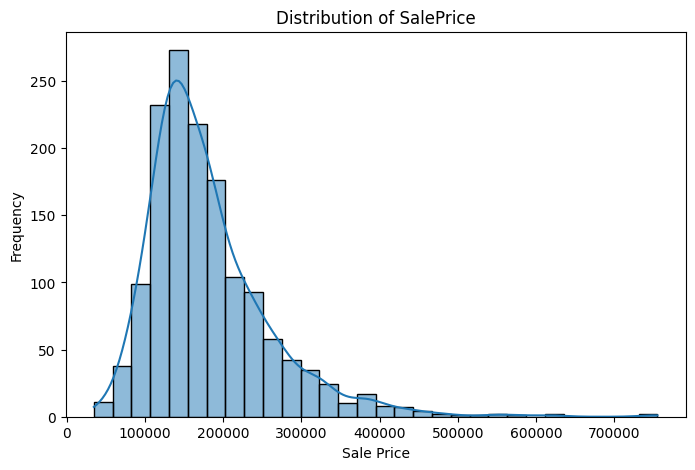

In [14]:
# Histogram of SalePrice
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

The histogram of SalePrice shows a **right-skewed (positively skewed) distribution.** The bulk of the data is concentrated between 100,000 and 200,000, with a long tail extending toward higher values. This indicate that while most houses are moderately priced, there is a smaller subset of very expensive properties that pull the mean above the median.

### Scatter plot: GrLivArea vs SalePrice with regression line

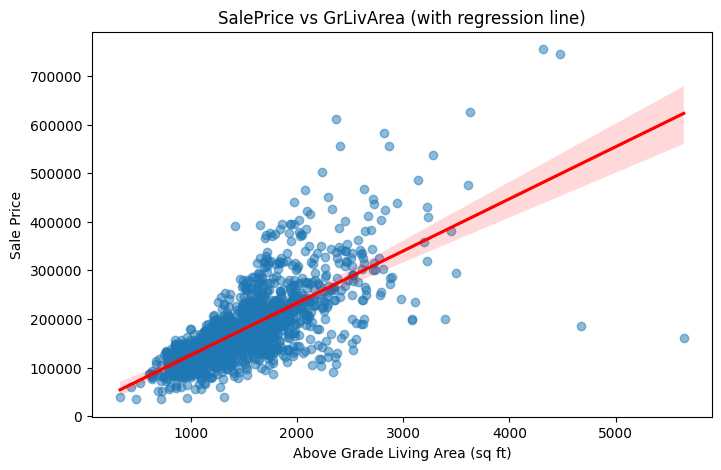

In [15]:
# Scatter plot: GrLivArea vs SalePrice with regression line
plt.figure(figsize=(8,5))
sns.regplot(x='GrLivArea', y='SalePrice', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('SalePrice vs GrLivArea (with regression line)')
plt.xlabel('Above Grade Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

* The plot shows a positive linear relationship, with some outliers (houses with large living area but relatively low price). 
* The regression line shows the average trend: as living area increases, price tends to increase. 
* There is heteroscedasticity (spread increases with area)  – the vertical spread of points widens as living area increases, meaning price variability is greater for larger homes.
* Points above the line are overpriced relative to size, below are underpriced. 
* Outliers could be influential. 
* The relationship is strong.

### Box plot: SalePrice by OverallQual

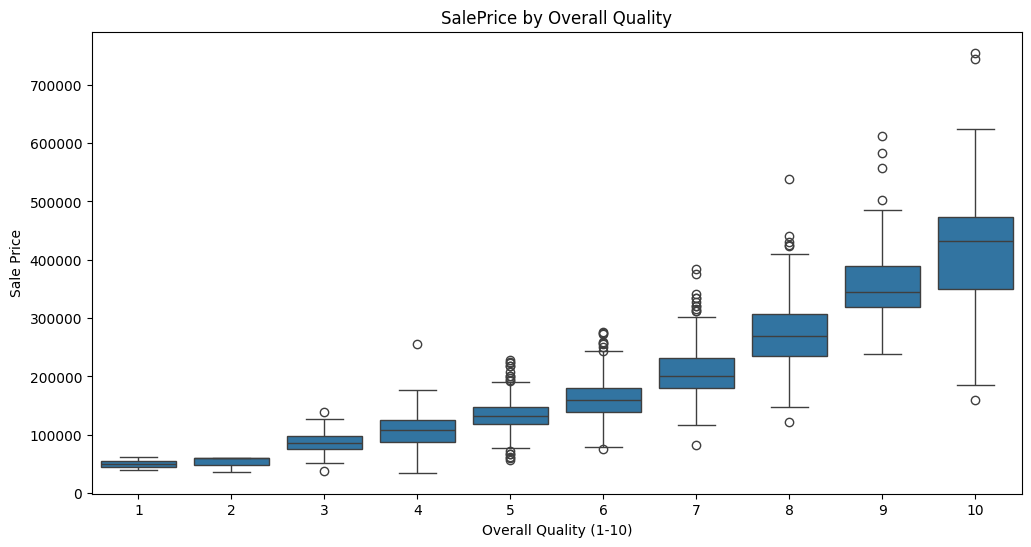

In [16]:
# Box plot: Sale Price by OverallQual
plt.figure(figsize=(12,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('SalePrice by Overall Quality')
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('Sale Price')
plt.show()

* The trend is clearly increasing median price with quality. 
* There's also increasing spread (variance) for higher qualities. 
* The monotonic relationship, the fact that higher quality houses are more expensive and also more variable, and that there are some low-quality houses (1-3) with very low prices and little spread. 

### Pair plot for top 5 features with highest correlation

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']


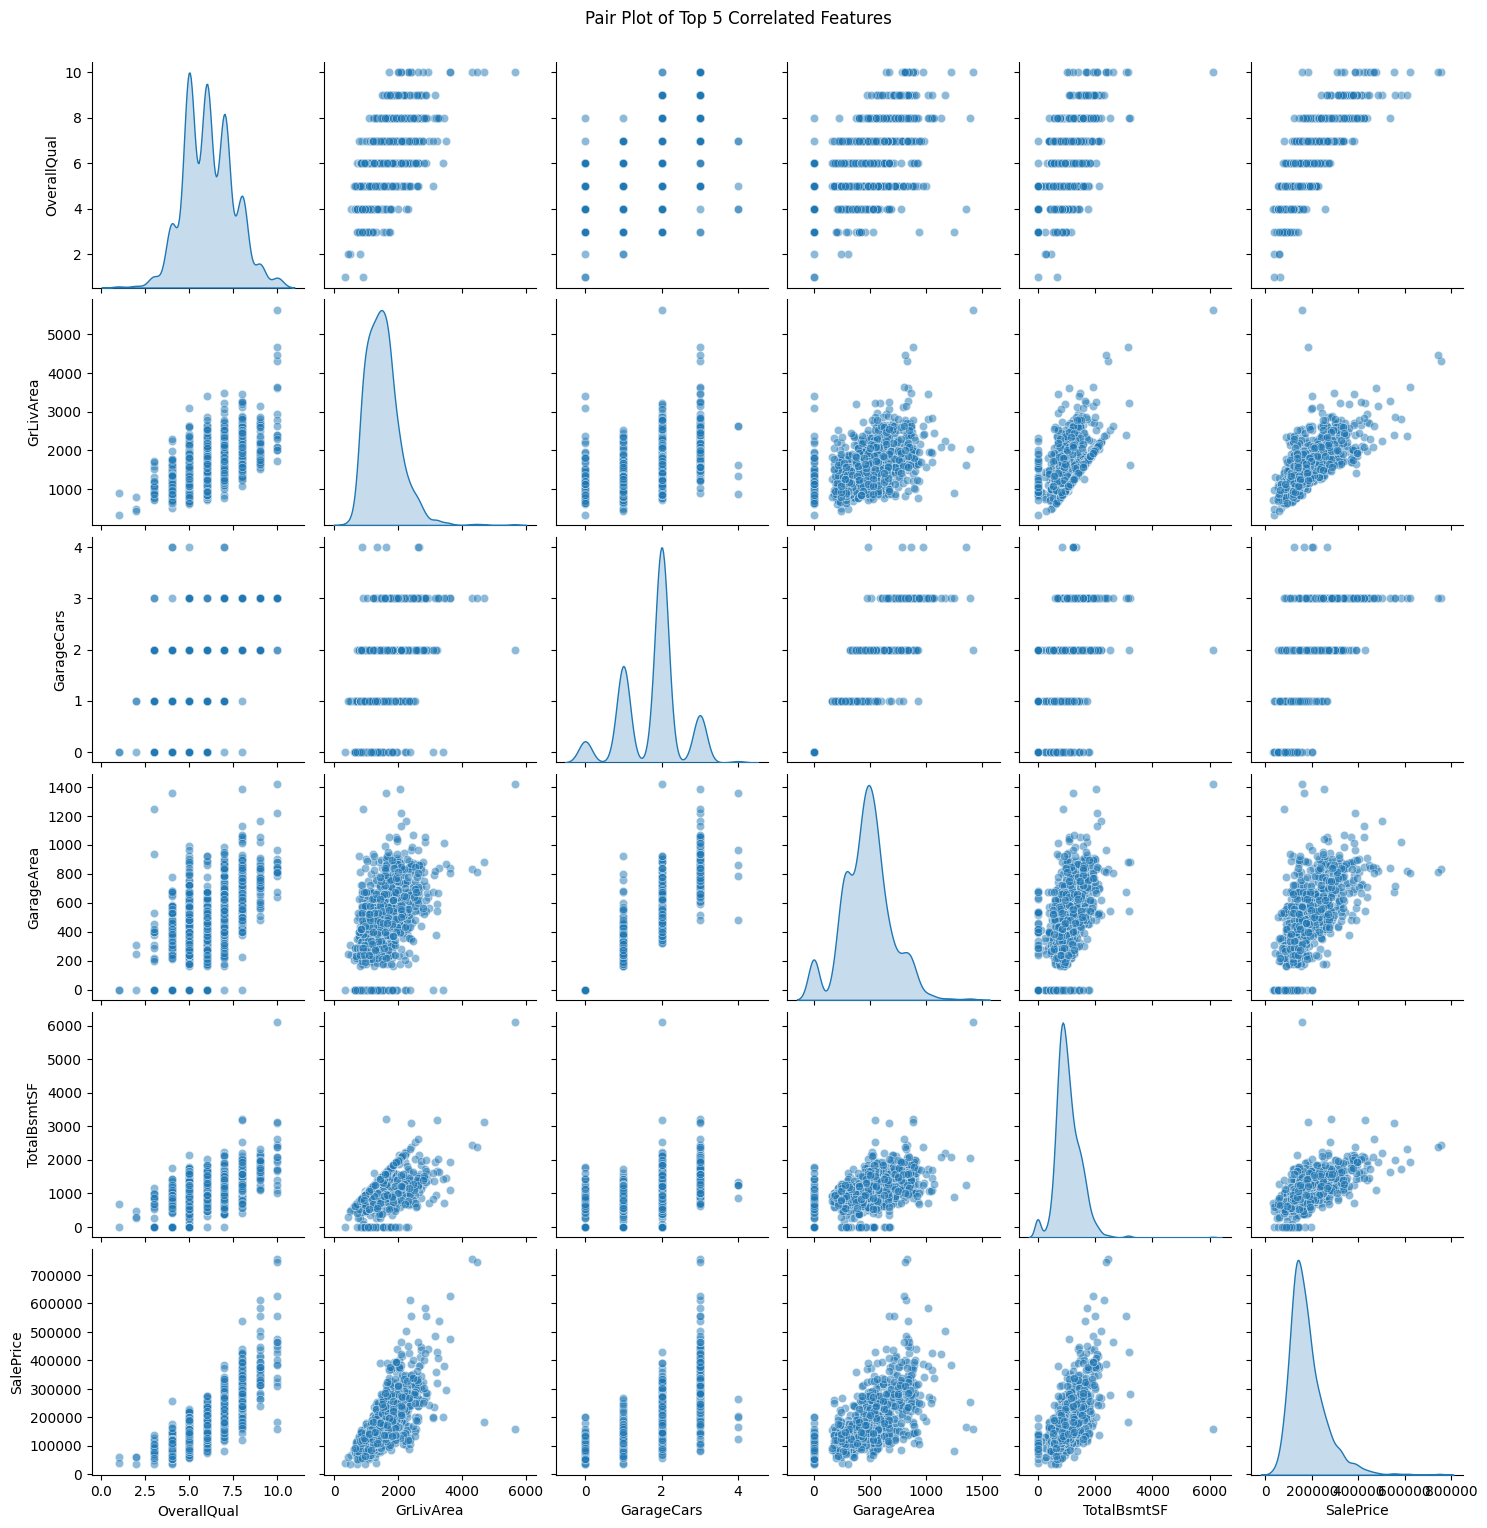

In [17]:
# Pair plot for top 5 features with highest correlation

# Get top 5 features (excluding SalePrice itself)
top_features = sale_corr.index[1:6] # top 5 after SalePrice
print("Top 5 features:", top_features.tolist())

# Include SalePrice in the pair plot
pair_vars = top_features.tolist() + ['SalePrice']
sns.pairplot(df[pair_vars], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pair Plot of Top 5 Correlated Features', y=1.02)
plt.show()

## Interpretation of Relationships Between Key Features and SalePrice

### 1. OverallQual (Overall Quality)

OverallQual is an ordinal variable ranging from 1 to 10 that measures the overall material and finish quality of the house.  
It shows the **strongest positive relationship with SalePrice**.

**Observation:**  
As the quality rating increases, the house price increases significantly.

**Insight:**  
Houses with ratings of **8 and above tend to have much higher prices**, while houses with ratings **5 and below generally fall into lower price ranges**. This indicates that construction quality and finishing materials are major determinants of house value.

---

### 2. GrLivArea (Above Ground Living Area)

GrLivArea represents the **above-ground living space in square feet**.

**Observation:**  
There is a strong **positive linear relationship** between living area and SalePrice. As the size of the living area increases, house prices also increase.

**Outliers:**  
A few houses with very large living areas appear to have unusually low prices. These points may represent **outliers** that could require further investigation or removal in predictive modeling.

---

### 3. TotalBsmtSF (Total Basement Area)

TotalBsmtSF represents the **total square footage of the basement**.

**Observation:**  
There is also a **positive relationship between basement size and house price**, although the points are more clustered compared to GrLivArea.

**Insight:**  
A larger basement increases property value by providing additional usable space, though it may have slightly less influence than the main living area.

---

### 4. GarageCars and GarageArea

Both variables measure garage capacity and size.

**GarageCars:**  
This represents the **number of cars the garage can hold**, so the plot shows vertical bands corresponding to discrete values (0–4 cars). As garage capacity increases, the sale price generally increases.

**GarageArea:**  
This measures the **garage size in square feet** and shows a continuous positive relationship with SalePrice.

**Insight:**  
Larger garages increase property value, although the price increase becomes less significant after about **three-car garage capacity**, suggesting diminishing returns.

---

## Summary of Correlation Strength

| Feature | Relationship with SalePrice | Key Observation |
|-------|-----------------------------|----------------|
| OverallQual | Very Strong Positive | Strongest predictor of house price |
| GrLivArea | Strong Positive | Larger living areas increase price |
| TotalBsmtSF | Moderate to Strong Positive | Basement space adds value |
| GarageCars | Strong Positive | Price increases with garage capacity |

---

## Distribution Patterns

The diagonal plots in the pair plot show **Kernel Density Estimate (KDE) distributions**.

- **SalePrice** is **right-skewed**, meaning most houses fall within a lower-to-middle price range, while a few houses are extremely expensive.
- **GrLivArea** and **TotalBsmtSF** also show **right-skewed distributions**, indicating that most houses have moderate space while only a few have very large areas.

**Conclusion:**  
The analysis suggests that **house quality, living space, basement size, and garage capacity are key factors influencing house prices** in this dataset.

# 6. Advanced Visualization and Insights
### Heatmap of correlation matrix with highlights

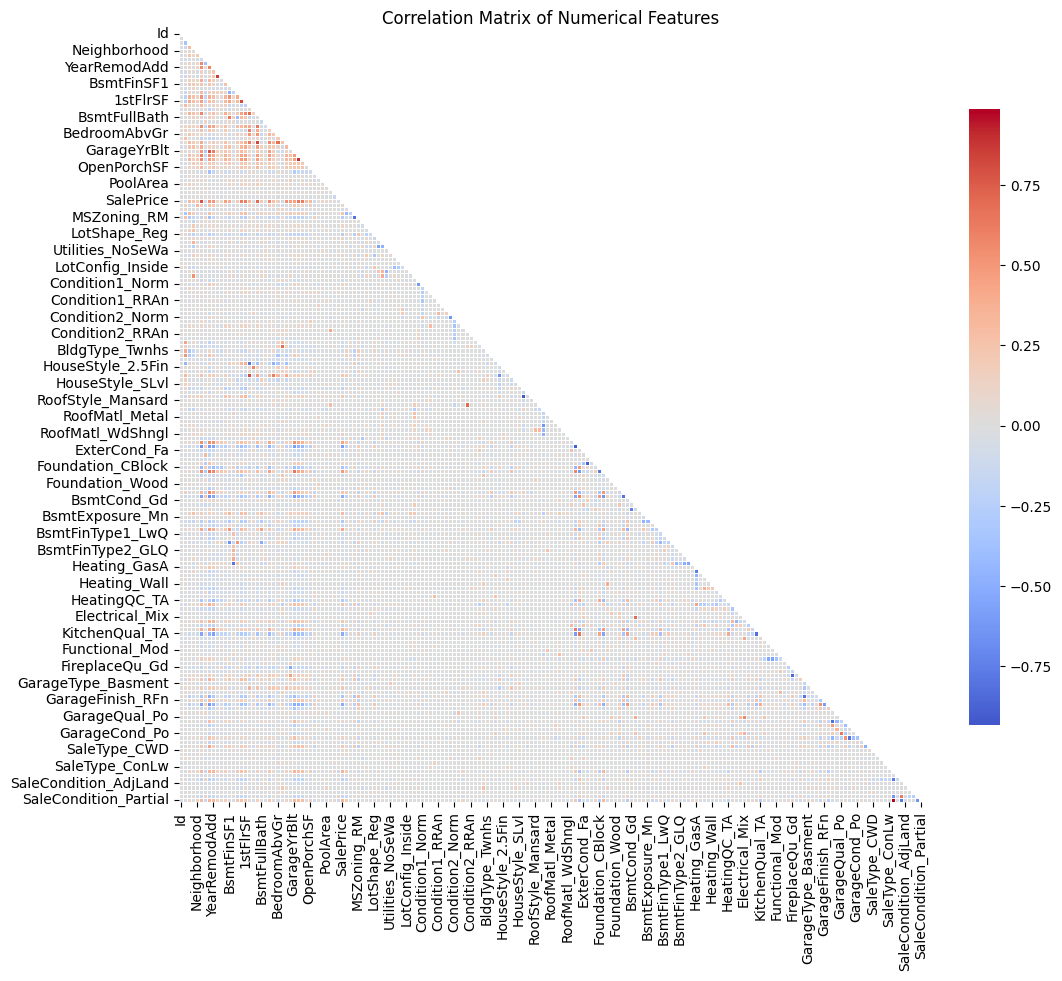

Features with |correlation| > 0.5 with SalePrice:
SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
YearRemodAdd        0.507101
GarageFinish_Unf   -0.513906
KitchenQual_TA     -0.519298
ExterQual_TA       -0.589044
Name: SalePrice, dtype: float64


In [18]:
# Heatmap of correlation matrix with highlights
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})


plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Identify strong correlations (|corr| > 0.5) with SalePrice
strong_corr = sale_corr[(sale_corr > 0.5) | (sale_corr < -0.5)]
print("Features with |correlation| > 0.5 with SalePrice:")
print(strong_corr)

## Interpretation of Key Correlations with SalePrice

### 1. The Strongest Drivers (Positive Correlation)

The following features show a **significant positive impact on home value**:

- **OverallQual (0.79)**  
  This is the **single most influential numerical feature**. Houses with higher material and finish quality tend to have much higher sale prices. Quality of construction is therefore the strongest predictor of property value.

- **GrLivArea (0.71)**  
  Size remains a major factor in determining price. The above-grade living area represents the main usable living space in the house, and larger homes generally sell for higher prices.

- **Garage Connectivity**  
  Both **GarageCars (0.64)** and **GarageArea (0.62)** are strongly correlated with SalePrice. Houses with larger garages or higher car capacity tend to be more valuable. However, these two features are also highly correlated with each other, suggesting **redundant information (multicollinearity)**.

---

### 2. Significant Negative Correlations

Several features related to **average quality ratings ("TA" – Typical/Average)** show strong negative correlations with SalePrice.

- **ExterQual_TA (-0.59)** and **KitchenQual_TA (-0.52)**  
  These results suggest that houses with **average-quality kitchens or exterior finishes** tend to sell for lower prices compared to houses with **Good or Excellent quality ratings**.

- **GarageFinish_Unf (-0.51)**  
  Houses with **unfinished garages** tend to have lower property values compared to homes with finished or semi-finished garages. This indicates that the level of finishing in functional spaces can significantly affect perceived house value.

---

## Noteworthy and Surprising Observations

### The "Size" Cluster

There is a high correlation between **TotalBsmtSF (0.61)** and **1stFlrSF (0.61)**.  
This relationship is expected because, in many houses, the **basement footprint is similar to the first-floor footprint**.

From a modeling perspective, including both variables may introduce **multicollinearity**, meaning the model receives overlapping information from two features.

---

### Quality Over Age

Although **YearBuilt (0.52)** and **YearRemodAdd (0.51)** are positively correlated with SalePrice, their impact is significantly smaller than **OverallQual (0.79)**.

This suggests that **construction quality matters more than age**. A well-maintained or high-quality older house can often be more valuable than a newer house built with average materials.

---

### Functional Redundancy

**TotRmsAbvGrd (0.53)** shows a lower correlation with SalePrice compared to **GrLivArea (0.71)**.

This indicates that **total square footage is a better predictor of house price than simply counting rooms**. For example, a spacious open-concept house with fewer rooms may be more valuable than a house with many small rooms.

---

### Conclusion

Overall, the correlation analysis highlights that **house quality, size, and functional space** are the most important factors influencing house prices. While age and renovation history also contribute to price differences, their impact is smaller compared to the overall construction quality and usable living space.

### Violin plot: SalePrice across YearBuilt bins

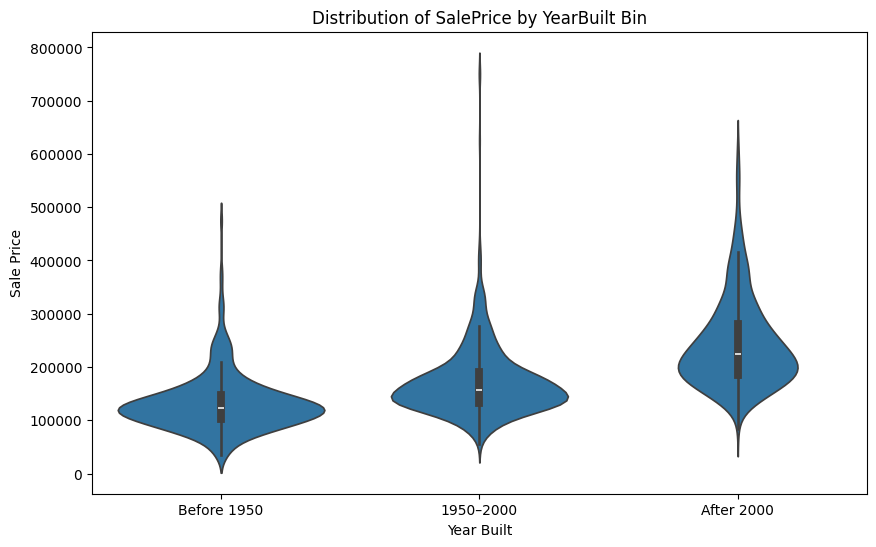

In [19]:
# Violin plot: SalePrice across YearBuilt bins

# Create bins for YearBuilt
bins = [0, 1950, 2000, df['YearBuilt'].max()]
labels = ['Before 1950', '1950–2000', 'After 2000']
df['YearBuiltBin'] = pd.cut(df['YearBuilt'], bins=bins, labels=labels)

plt.figure(figsize=(10,6))
sns.violinplot(x='YearBuiltBin', y='SalePrice', data=df)
plt.title('Distribution of SalePrice by YearBuilt Bin')
plt.xlabel('Year Built')
plt.ylabel('Sale Price')
plt.show()

## Violin Plot Interpretation: SalePrice by YearBuilt Bins

### Observed Trends

#### Increasing Median Price with Newer Construction
The **median (white dot inside each violin)** rises steadily across the three bins:

- **Lowest** for homes built **before 1950**
- **Higher** for homes built between **1950–2000**
- **Highest** for homes built **after 2000**

This pattern confirms that **newer homes generally command higher prices**, reflecting improvements in modern construction standards, materials, energy efficiency, and architectural layouts.

---

#### Expanding Spread and Higher Upper Tail

- The **before-1950 violin** is relatively narrow and concentrated at lower prices, indicating that most older homes fall within a modest price range.

- The **1950–2000 group** shows a wider distribution, with a noticeable upper tail extending beyond **300,000**.

- The **after-2000 violin** is the widest, with a very long upper tail reaching up to **700,000–800,000**.  
  This suggests that while many newer homes are moderately priced, a substantial portion belong to the **luxury housing segment**, which increases the maximum values.

---

#### Shape of Distributions

- **Pre-1950 homes** show a roughly symmetric distribution around a lower median, possibly with a slight right skew due to renovated or historically valuable homes.

- The **1950–2000 distribution** is more spread out and may show a secondary concentration at higher prices, suggesting a mix of **modest suburban homes and some higher-end properties**.

- **After-2000 homes** display a strongly **right-skewed distribution**. Most homes fall between **150,000 and 300,000**, but the long tail indicates the presence of **very expensive new builds**.

---

#### Outliers

All three construction periods contain **outliers above the whiskers**, but they are most prominent in the **after-2000 group**, where several houses exceed **600,000**.  
These properties are likely **custom-built or luxury homes located in premium neighborhoods**.

---

## Interpretation

### Age–Value Relationship
Although newer homes generally have higher prices, there is **considerable overlap between the three bins**. This means that **age alone does not fully determine house value**. Some **pre-1950 homes**, especially those that have been renovated or are located in historic areas, can reach prices comparable to newer houses.

---

### Market Segmentation
The **increasing spread in recent decades** reflects growing diversity in the housing market. Modern housing developments include both **affordable homes and luxury custom-built houses**, whereas older housing stock tends to be **more uniform and moderately priced**.

---

### Practical Implication for Modeling
The variable **YearBuilt** should definitely be included in predictive models. However, its effect may be **nonlinear**, meaning that a simple linear relationship might not capture the sudden increase in prices for homes built after 2000.  
Using **binned variables, transformations, or spline functions** may better capture this relationship.

---

## Conclusion
The violin plot clearly illustrates that **construction era is an important factor influencing house prices**. Newer homes generally have higher values and a wider price range, largely due to the emergence of a **luxury housing segment in the most recent construction period**.

### Bar plot: Mean SalePrice for top 10 most common Exterior1st materials

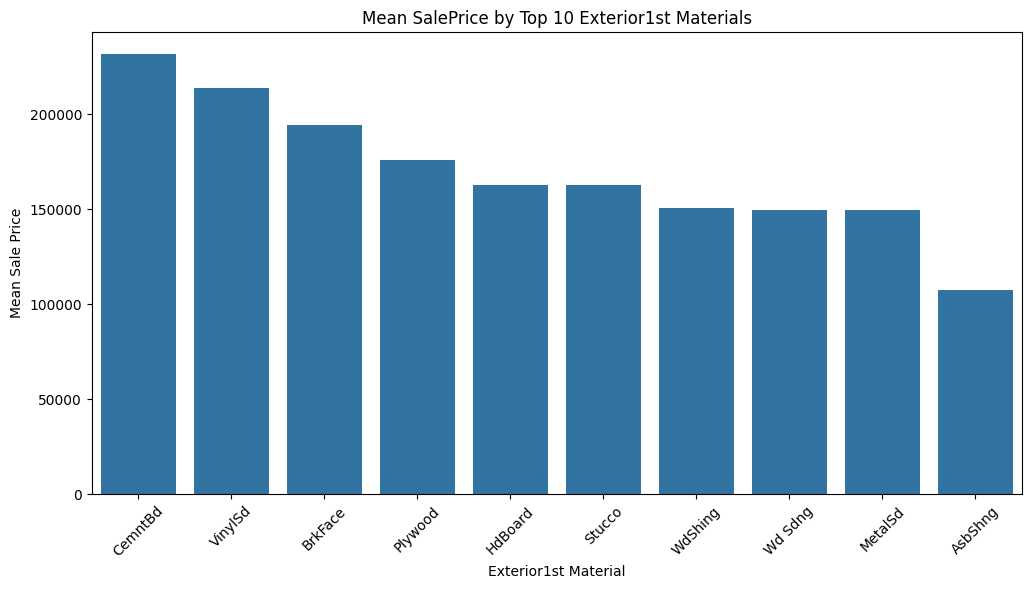

In [20]:
original_df = pd.read_csv('train.csv')

# Get top 10 Exterior1st
top_exterior = original_df['Exterior1st'].value_counts().head(10).index

# Compute mean SalePrice for each
mean_prices = original_df[original_df['Exterior1st'].isin(top_exterior)].groupby('Exterior1st')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=mean_prices.index, y=mean_prices.values)
plt.title('Mean SalePrice by Top 10 Exterior1st Materials')
plt.xlabel('Exterior1st Material')
plt.ylabel('Mean Sale Price')
plt.xticks(rotation=45)
plt.show()

### Interpretation
* Exterior material is a strong proxy for overall house quality and value. Premium materials like cemntBd are associated with higher‑end construction, while economy materials correlate with entry‑level or older homes.

* The wide spread in mean prices (from 100,000 for AsbSgng to 250,000+ for CemntBd) confirms that Exterior1st captures important variation not fully explained by other features like OverallQual alone.

* In a predictive model, this categorical variable should be retained (via one‑hot encoding) because it provides a clear, interpretable signal of expected price tier.